   LotArea  OverallQual  GrLivArea  GarageCars  ExterCond  SalePrice
0     7770            2       3352           1       Good     330519
1     1360            1       1015           2       Poor      65088
2     5890            6       3279           3  Excellent     369759
3    13918            5       1887           3  Excellent     422282
4     5691            9       3953           3  Excellent     226118
Random Forest Regression - MAE: 126181.70, MSE: 21107148167.05, RMSE: 145282.99, R^2: -0.12
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best Hyperparameters: {'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
Tuned Random Forest Regression - MAE: 124418.09, MSE: 20039840994.06, RMSE: 141562.15, R^2: -0.06


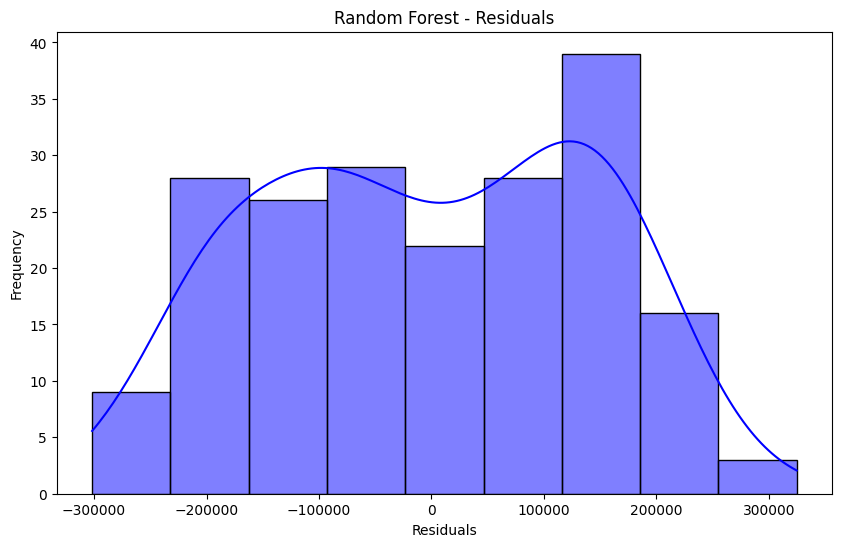

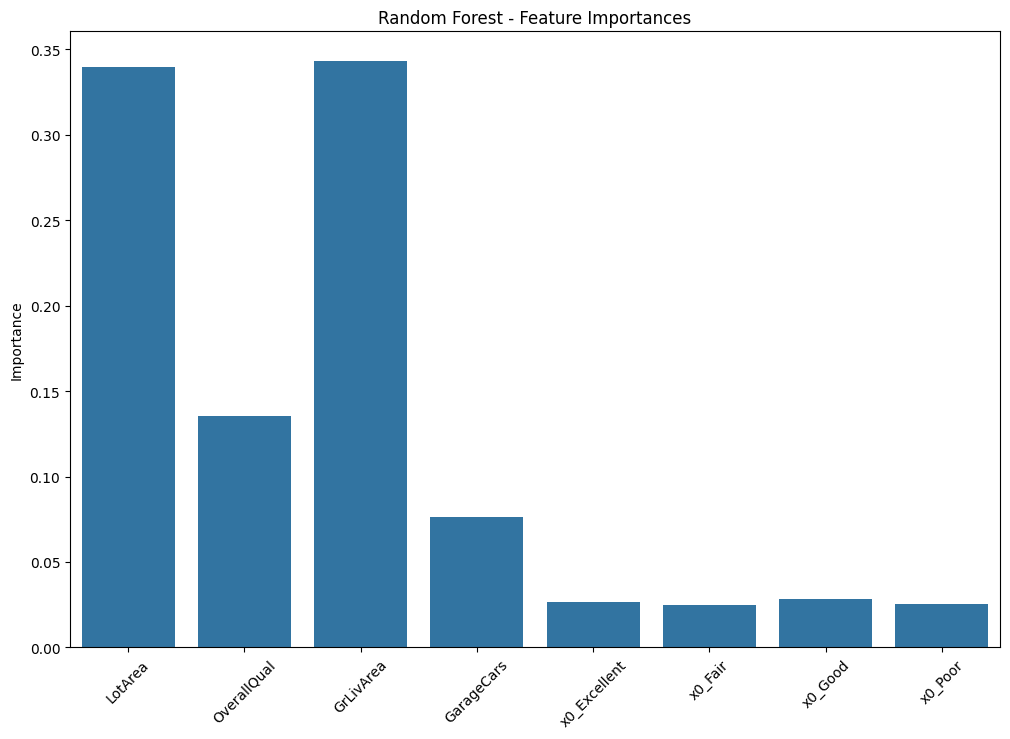

Linear Regression - MAE: 123886.95, MSE: 19088821700.09, RMSE: 138162.30, R^2: -0.01


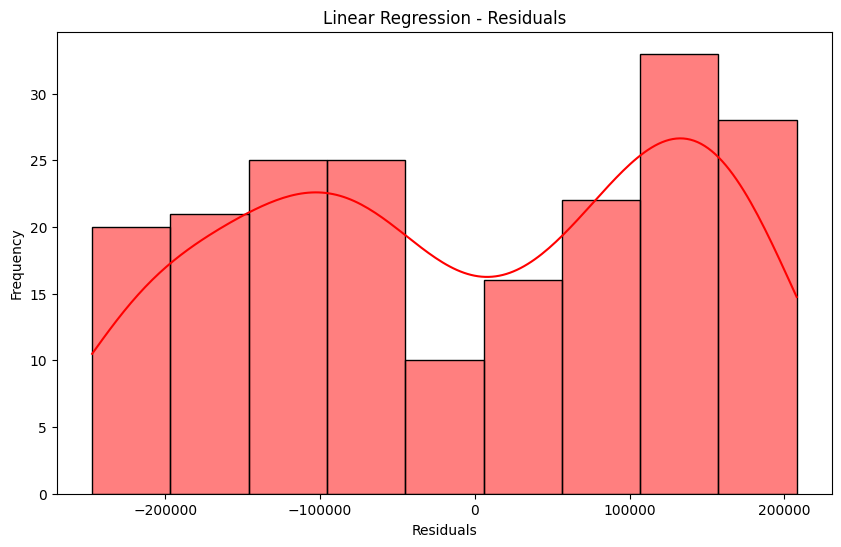

C:\Users\admin\AppData\Local\Temp\ipykernel_18808\32881137.py:162: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=r2_scores, palette='Blues_d')


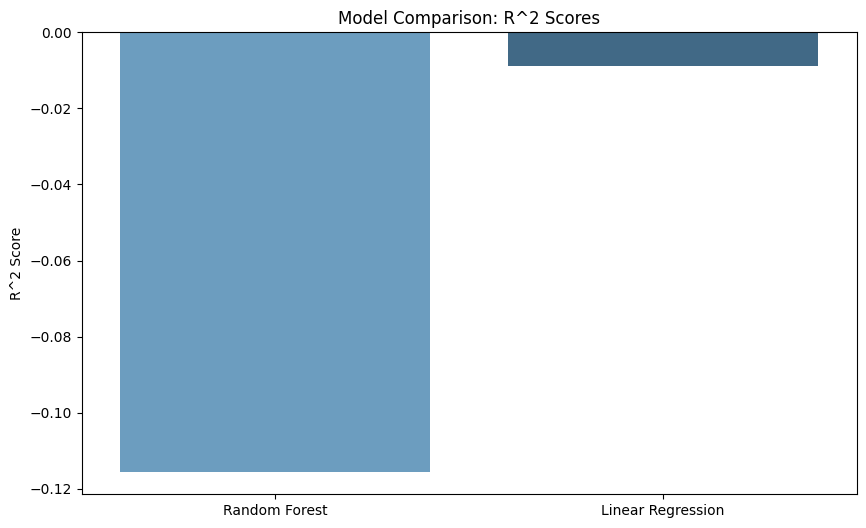

C:\Users\admin\AppData\Local\Temp\ipykernel_18808\32881137.py:169: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=mae_scores, palette='Reds_d')


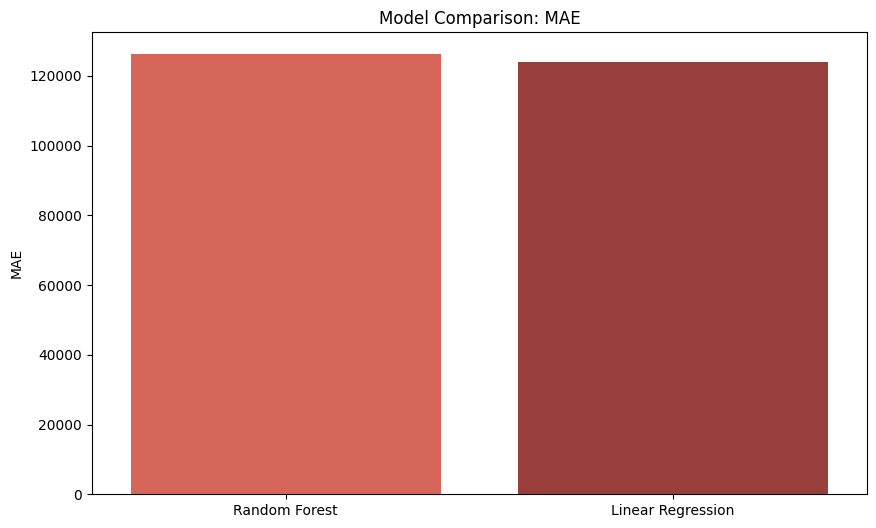

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)

n_samples=1000

data=pd.DataFrame({
    'LotArea': np.random.randint(500, 15000, n_samples),
    'OverallQual': np.random.randint(1, 11, n_samples),  
    'GrLivArea': np.random.randint(500, 4000, n_samples), 
    'GarageCars': np.random.randint(0, 4, n_samples),  
    'ExterCond': np.random.choice(['Excellent', 'Good', 'Fair', 'Poor'], n_samples),  
    'SalePrice': np.random.randint(50000, 500000, n_samples)  
})

print(data.head())

X=data.drop('SalePrice',axis=1)
y=data['SalePrice']


numeric_features = ['LotArea', 'OverallQual', 'GrLivArea', 'GarageCars']
categorical_features = ['ExterCond']

# Preprocessing for numeric columns: Scaling and Imputation
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Preprocessing for categorical columns: Imputation and One-Hot Encoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine the transformers into a column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Train-test split (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create pipeline with preprocessor and RandomForestRegressor
rf_model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Train the RandomForest model
rf_model_pipeline.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model_pipeline.predict(X_test)

# Evaluate the model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Regression - MAE: {mae_rf:.2f}, MSE: {mse_rf:.2f}, RMSE: {rmse_rf:.2f}, R^2: {r2_rf:.2f}")

# Hyperparameter Tuning with GridSearchCV
param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5, 10]
}

# Perform GridSearchCV to find the best parameters
grid_search = GridSearchCV(rf_model_pipeline, param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# Best hyperparameters from grid search
print("Best Hyperparameters:", grid_search.best_params_)

# Evaluating the tuned model
y_pred_tuned = grid_search.predict(X_test)
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mse_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print(f"Tuned Random Forest Regression - MAE: {mae_tuned:.2f}, MSE: {mse_tuned:.2f}, RMSE: {rmse_tuned:.2f}, R^2: {r2_tuned:.2f}")

# Visualizations: Residuals Plot and Feature Importance
residuals_rf = y_test - y_pred_rf

# Residuals Plot (Random Forest)
plt.figure(figsize=(10, 6))
sns.histplot(residuals_rf, kde=True, color='blue')
plt.title('Random Forest - Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

# Feature Importance Plot (Random Forest)
importances_rf = rf_model_pipeline.named_steps['classifier'].feature_importances_
features_rf = numeric_features + list(rf_model_pipeline.named_steps['preprocessor'].transformers_[1][1].named_steps['onehot'].get_feature_names_out())

# Plotting feature importance (Random Forest)
plt.figure(figsize=(12, 8))
sns.barplot(x=features_rf, y=importances_rf)
plt.xticks(rotation=45)
plt.title("Random Forest - Feature Importances")
plt.ylabel("Importance")
plt.show()

# Linear Regression Model for Comparison
lr_model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LinearRegression())
])

# Train the Linear Regression model
lr_model_pipeline.fit(X_train, y_train)

# Predictions for Linear Regression
y_pred_lr = lr_model_pipeline.predict(X_test)

# Evaluate the Linear Regression model
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression - MAE: {mae_lr:.2f}, MSE: {mse_lr:.2f}, RMSE: {rmse_lr:.2f}, R^2: {r2_lr:.2f}")

# Visualizing Residuals for Linear Regression
residuals_lr = y_test - y_pred_lr

plt.figure(figsize=(10, 6))
sns.histplot(residuals_lr, kde=True, color='red')
plt.title('Linear Regression - Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

# Model Comparison Plot: Random Forest vs Linear Regression
models = ['Random Forest', 'Linear Regression']
r2_scores = [r2_rf, r2_lr]
mae_scores = [mae_rf, mae_lr]

# Bar plot for R^2 scores comparison
plt.figure(figsize=(10, 6))
sns.barplot(x=models, y=r2_scores, palette='Blues_d')
plt.title('Model Comparison: R^2 Scores')
plt.ylabel('R^2 Score')
plt.show()

# Bar plot for MAE comparison
plt.figure(figsize=(10, 6))
sns.barplot(x=models, y=mae_scores, palette='Reds_d')
plt.title('Model Comparison: MAE')
plt.ylabel('MAE')
plt.show()
